# IRIS - Benchmark academique des modeles ML non supervises

Ce notebook compare plusieurs modeles non supervises pour le **signal d'atypicite statistique** du Claim Attention Score IRIS.

Positionnement important : IRIS est une aide a l'analyse et a la priorisation des dossiers sinistres automobiles. Les resultats ci-dessous ne constituent pas une decision automatique, une preuve, ni une conclusion juridique. Les libelles utilises restent prudents : dossier atypique a examiner, signal d'atypicite statistique, element a verifier, examen prioritaire suggere.

Le module ML operationnel candidat reste `IRIS_CLAIM_ML_ANOMALY_SIGNAL_V1_CANDIDATE`. Ce notebook sert uniquement a comparer des alternatives academiques sur les memes features.


## Objectifs du benchmark

Comparer les modeles suivants quand leurs dependances sont disponibles :

1. Isolation Forest
2. Local Outlier Factor
3. One-Class SVM
4. Robust Covariance / EllipticEnvelope
5. HBOS via une implementation locale simple, sans dependance pyod
6. Autoencoder simple via scikit-learn sur echantillon controle

Sans labels humains confirmes, ce notebook ne mesure pas une performance supervisee sur labels humains. Il compare plutot : stabilite des top dossiers, recouvrement avec les regles metier, recouvrement avec post-inspection, simplicite d'explication, temps d'execution, robustesse sur grand volume, score percentile comprehensible et facilite d'integration IRIS.


In [1]:
from __future__ import annotations

import json
import math
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

def find_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if candidate.name == "IRIS_AUTO_FRAUD" and (candidate / "etl" / "dwh" / "dwh_utils.py").exists():
            return candidate
        nested = candidate / "IRIS_AUTO_FRAUD"
        if (nested / "etl" / "dwh" / "dwh_utils.py").exists():
            return nested
    raise RuntimeError("Impossible de localiser le repo IRIS_AUTO_FRAUD depuis le dossier courant.")

BASE_DIR = find_repo_root(Path.cwd().resolve())

for import_path in [BASE_DIR, BASE_DIR / "etl" / "dwh"]:
    import_path_text = str(import_path)
    if import_path_text not in sys.path:
        sys.path.insert(0, import_path_text)

from sqlalchemy import text
import dwh_utils

from etl.mart.compute_claim_scoring_features_v1 import FEATURE_VERSION
from etl.mart.compute_claim_ml_anomaly_signal_v1_candidate import (
    CONFIG_PATH,
    SIGNAL_VERSION as ML_SIGNAL_VERSION,
    load_ml_config,
    prepare_ml_feature_matrix,
    percentile_scores,
)
from etl.mart.compute_claim_attention_hybrid_score_v1_candidate import SCORE_VERSION as HYBRID_SCORE_VERSION
from etl.mart.compute_claim_attention_hybrid_ml_score_v1_candidate import SCORE_VERSION as HYBRID_ML_SCORE_VERSION
from etl.mart.compute_post_inspection_attention_signal_v1_candidate import SIGNAL_VERSION as POST_INSPECTION_SIGNAL_VERSION

REPORT_DIR = BASE_DIR / "data" / "quality_reports" / "scoring" / "ml_model_benchmark"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
BENCHMARK_SAMPLE_ROWS = 50000
OCSVM_SAMPLE_ROWS = 10000
RUN_FULL_ISOLATION_FOREST_IF_NO_DB_SIGNAL = False

print(f"BASE_DIR={BASE_DIR}")
print(f"REPORT_DIR={REPORT_DIR}")


BASE_DIR=C:\Users\wiem\Downloads\Projet PFE\IRIS_AUTO_FRAUD
REPORT_DIR=C:\Users\wiem\Downloads\Projet PFE\IRIS_AUTO_FRAUD\data\quality_reports\scoring\ml_model_benchmark


## Connexion PostgreSQL en lecture seule

La base PostgreSQL est utilisee comme source de verite, mais ce notebook ne fait aucune ecriture PostgreSQL. Les seules sorties ecrites sont des petits rapports locaux dans `data/quality_reports/scoring/ml_model_benchmark/`.


In [2]:
logger = dwh_utils.setup_logging("ML_MODEL_BENCHMARK_READ_ONLY", log_name="ml_model_benchmark_read_only")
engine = dwh_utils.build_engine(logger)


def latest_run_id(table_name: str, run_column: str, version_column: str, version: str) -> str | None:
    query = text(f"""
        SELECT {run_column}
        FROM {table_name}
        WHERE {version_column} = :version
        GROUP BY {run_column}
        ORDER BY MAX(created_at) DESC
        LIMIT 1
    """)
    with engine.connect() as conn:
        row = conn.execute(query, {"version": version}).fetchone()
    return None if row is None else str(row[0])

feature_run_id = latest_run_id(
    "mart.fact_claim_scoring_features",
    "feature_run_id",
    "scoring_feature_version",
    FEATURE_VERSION,
)
post_inspection_run_id = latest_run_id(
    "mart.fact_post_inspection_attention_signal",
    "signal_run_id",
    "signal_version",
    POST_INSPECTION_SIGNAL_VERSION,
)
ml_signal_run_id = latest_run_id(
    "mart.fact_claim_ml_anomaly_signal",
    "signal_run_id",
    "signal_version",
    ML_SIGNAL_VERSION,
)
hybrid_score_run_id = latest_run_id(
    "mart.fact_claim_attention_score",
    "score_run_id",
    "score_version",
    HYBRID_SCORE_VERSION,
)
hybrid_ml_score_run_id = latest_run_id(
    "mart.fact_claim_attention_score",
    "score_run_id",
    "score_version",
    HYBRID_ML_SCORE_VERSION,
)

run_context = pd.DataFrame([{
    "feature_run_id": feature_run_id,
    "post_inspection_run_id": post_inspection_run_id,
    "ml_signal_run_id": ml_signal_run_id,
    "hybrid_score_run_id": hybrid_score_run_id,
    "hybrid_ml_score_run_id": hybrid_ml_score_run_id,
}])
run_context


2026-07-09 10:40:20 | INFO     | Logger initialise | run_id=ML_MODEL_BENCHMARK_READ_ONLY | log=C:\Users\wiem\Downloads\Projet PFE\IRIS_AUTO_FRAUD\logs\ml_model_benchmark_read_only_ML_MODEL_BENCHMARK_READ_ONLY.log
2026-07-09 10:40:20 | INFO     | Engine PostgreSQL : localhost:5432/iris_auto_fraud


,feature_run_id,post_inspection_run_id,ml_signal_run_id,hybrid_score_run_id,hybrid_ml_score_run_id
0,IRIS_CLAIM_ATTENTION_FEATURES_V1_CANDIDATE_202...,IRIS_POST_INSPECTION_SIGNAL_V1_CANDIDATE_20260...,IRIS_CLAIM_ML_ANOMALY_SIGNAL_V1_CANDIDATE_2026...,IRIS_CLAIM_ATTENTION_HYBRID_V1_CANDIDATE_20260...,IRIS_CLAIM_ATTENTION_HYBRID_ML_V1_CANDIDATE_20...


In [3]:
# IRIS_INTERPRETATION_CELL
available_runs = run_context.iloc[0].dropna().to_dict()
display(Markdown(f"""
**Interpretation du contexte d'execution**  
Cette cellule verifie que le notebook travaille sur les derniers runs disponibles, sans ecriture PostgreSQL.  
Runs disponibles detectes : `{len(available_runs)}`. Le benchmark est donc rattache a une lineage claire : features, post-inspection, signal ML et score hybride si disponibles.
"""))



**Interpretation du contexte d'execution**  
Cette cellule verifie que le notebook travaille sur les derniers runs disponibles, sans ecriture PostgreSQL.  
Runs disponibles detectes : `5`. Le benchmark est donc rattache a une lineage claire : features, post-inspection, signal ML et score hybride si disponibles.


In [4]:
if feature_run_id is None:
    raise RuntimeError("Aucun feature_run_id trouve pour le Claim Attention feature mart.")

features_query = text("""
    SELECT *
    FROM mart.fact_claim_scoring_features
    WHERE scoring_feature_version = :version
      AND feature_run_id = :run_id
""")
with engine.connect() as conn:
    features_df = pd.read_sql(features_query, conn, params={"version": FEATURE_VERSION, "run_id": feature_run_id})

if post_inspection_run_id:
    post_query = text("""
        SELECT *
        FROM mart.fact_post_inspection_attention_signal
        WHERE signal_version = :version
          AND signal_run_id = :run_id
    """)
    with engine.connect() as conn:
        post_inspection_df = pd.read_sql(post_query, conn, params={"version": POST_INSPECTION_SIGNAL_VERSION, "run_id": post_inspection_run_id})
else:
    post_inspection_df = pd.DataFrame()

if ml_signal_run_id:
    ml_query = text("""
        SELECT claim_sk, raw_anomaly_score, score_ml, ml_attention_points, top_variable_1, top_variable_2, top_variable_3
        FROM mart.fact_claim_ml_anomaly_signal
        WHERE signal_version = :version
          AND signal_run_id = :run_id
    """)
    with engine.connect() as conn:
        existing_ml_df = pd.read_sql(ml_query, conn, params={"version": ML_SIGNAL_VERSION, "run_id": ml_signal_run_id})
else:
    existing_ml_df = pd.DataFrame()

# Reference metier principale: toujours le score Hybrid deterministe sans ML.
# Cela evite toute circularite: Isolation Forest ne doit pas etre compare a un score qui contient deja Isolation Forest.
score_version_to_compare = HYBRID_SCORE_VERSION
score_run_id_to_compare = hybrid_score_run_id
if score_run_id_to_compare:
    score_query = text("""
        SELECT claim_sk, attention_score, attention_level, main_reason_1, main_reason_2, main_reason_3
        FROM mart.fact_claim_attention_score
        WHERE score_version = :version
          AND score_run_id = :run_id
    """)
    with engine.connect() as conn:
        attention_df = pd.read_sql(score_query, conn, params={"version": score_version_to_compare, "run_id": score_run_id_to_compare})
else:
    attention_df = pd.DataFrame()

# Comparaison secondaire uniquement: Hybrid ML, non utilise comme reference metier principale.
if hybrid_ml_score_run_id:
    score_ml_query = text("""
        SELECT claim_sk, attention_score, attention_level, main_reason_1, main_reason_2, main_reason_3
        FROM mart.fact_claim_attention_score
        WHERE score_version = :version
          AND score_run_id = :run_id
    """)
    with engine.connect() as conn:
        attention_ml_df = pd.read_sql(score_ml_query, conn, params={"version": HYBRID_ML_SCORE_VERSION, "run_id": hybrid_ml_score_run_id})
else:
    attention_ml_df = pd.DataFrame()

print(f"features_df={len(features_df):,}")
print(f"post_inspection_df={len(post_inspection_df):,}")
print(f"existing_ml_df={len(existing_ml_df):,}")
print(f"attention_df={len(attention_df):,} version={score_version_to_compare if score_run_id_to_compare else None}")
print(f"attention_ml_df={len(attention_ml_df):,} version={HYBRID_ML_SCORE_VERSION if hybrid_ml_score_run_id else None} (comparaison secondaire)")


features_df=381,893
post_inspection_df=148
existing_ml_df=381,893
attention_df=381,893 version=IRIS_CLAIM_ATTENTION_HYBRID_V1_CANDIDATE
attention_ml_df=381,893 version=IRIS_CLAIM_ATTENTION_HYBRID_ML_V1_CANDIDATE (comparaison secondaire)


In [5]:
# IRIS_INTERPRETATION_CELL
data_points = [
    f"features: {len(features_df):,}",
    f"post-inspection signals: {len(post_inspection_df):,}",
    f"ML signal reference: {len(existing_ml_df):,}",
    f"attention score comparison: {len(attention_df):,}",
]
display(Markdown("""
**Interpretation du chargement des donnees**  
Le benchmark dispose d'un socle suffisant si le nombre de lignes features correspond au perimetre sinistres attendu et si le signal ML de reference est disponible.  
Dans ce run : {points}. Cela permet de comparer les modeles sans recalculer ni modifier les marts operationnels.
""".format(points=" ; ".join(data_points))))



**Interpretation du chargement des donnees**  
Le benchmark dispose d'un socle suffisant si le nombre de lignes features correspond au perimetre sinistres attendu et si le signal ML de reference est disponible.  
Dans ce run : features: 381,893 ; post-inspection signals: 148 ; ML signal reference: 381,893 ; attention score comparison: 381,893. Cela permet de comparer les modeles sans recalculer ni modifier les marts operationnels.


## Comparaison secondaire Hybrid vs Hybrid ML

La reference metier principale du benchmark reste le score **Hybrid deterministe sans ML**. Le score Hybrid ML est affiche uniquement comme comparaison secondaire pour mesurer l'effet du signal ML dans le score global. Il n'est pas utilise pour calculer l'overlap metier principal afin d'eviter une circularite.


In [6]:
if not attention_df.empty and not attention_ml_df.empty:
    hybrid_compare_df = attention_df[["claim_sk", "attention_score", "attention_level"]].rename(columns={
        "attention_score": "hybrid_score_without_ml",
        "attention_level": "hybrid_level_without_ml",
    }).merge(
        attention_ml_df[["claim_sk", "attention_score", "attention_level"]].rename(columns={
            "attention_score": "hybrid_score_with_ml",
            "attention_level": "hybrid_level_with_ml",
        }),
        on="claim_sk",
        how="inner",
    )
    hybrid_compare_df["ml_increment"] = hybrid_compare_df["hybrid_score_with_ml"] - hybrid_compare_df["hybrid_score_without_ml"]
    hybrid_secondary_summary = pd.DataFrame([{
        "matched_claims": len(hybrid_compare_df),
        "mean_increment": float(hybrid_compare_df["ml_increment"].mean()),
        "median_increment": float(hybrid_compare_df["ml_increment"].median()),
        "claims_with_positive_increment": int((hybrid_compare_df["ml_increment"] > 0).sum()),
        "max_increment": int(hybrid_compare_df["ml_increment"].max()),
    }])
    display(hybrid_secondary_summary)
    display(hybrid_compare_df["ml_increment"].value_counts().sort_index().rename_axis("ml_increment").reset_index(name="claims"))
else:
    hybrid_secondary_summary = pd.DataFrame(columns=["matched_claims", "mean_increment", "median_increment", "claims_with_positive_increment", "max_increment"])
    display(Markdown("**Comparaison secondaire non disponible** : score Hybrid ML ou Hybrid deterministe absent."))


,matched_claims,mean_increment,median_increment,claims_with_positive_increment,max_increment
0,381893,0.610011,0.0,38190,10


,ml_increment,claims
0,0,343703
1,4,19095
2,7,11457
3,10,7638


In [7]:
# IRIS_INTERPRETATION_CELL
if "hybrid_secondary_summary" in globals() and not hybrid_secondary_summary.empty:
    row = hybrid_secondary_summary.iloc[0]
    display(Markdown(f"""
**Interpretation de la comparaison secondaire Hybrid ML**  
Le score Hybrid ML sert a observer l'effet marginal du signal ML, pas a definir la reference metier du benchmark.  
Dossiers compares : `{int(row['matched_claims']):,}` ; dossiers avec increment positif : `{int(row['claims_with_positive_increment']):,}` ; increment maximal : `{int(row['max_increment'])}` points.  
Cette lecture confirme l'impact du ML dans la version enrichie, mais l'overlap metier principal reste calcule sur Hybrid deterministe sans ML.
"""))



**Interpretation de la comparaison secondaire Hybrid ML**  
Le score Hybrid ML sert a observer l'effet marginal du signal ML, pas a definir la reference metier du benchmark.  
Dossiers compares : `381,893` ; dossiers avec increment positif : `38,190` ; increment maximal : `10` points.  
Cette lecture confirme l'impact du ML dans la version enrichie, mais l'overlap metier principal reste calcule sur Hybrid deterministe sans ML.


## Construction du dataset ML

Les features proviennent de la meme configuration que le module ML candidat. Si certaines colonnes ne sont pas disponibles, le notebook les signale et continue avec les colonnes disponibles ou reconstruites. Les valeurs manquantes sont imputees par mediane, les valeurs extremes sont clippees, puis les variables sont standardisees pour les modeles sensibles au scaling.


In [8]:
ml_config = load_ml_config(CONFIG_PATH)
expected_features = list(ml_config["features"])

enriched_df, X_ml, imputation_values = prepare_ml_feature_matrix(features_df, post_inspection_df, ml_config)
used_features = list(X_ml.columns)
missing_features = [col for col in expected_features if col not in enriched_df.columns]
available_features = [col for col in expected_features if col in enriched_df.columns]

feature_audit = pd.DataFrame({
    "feature": expected_features,
    "available_after_preparation": [feature in used_features for feature in expected_features],
    "imputation_value": [imputation_values.get(feature) for feature in expected_features],
})

print(f"Lignes X_ml: {len(X_ml):,}")
print(f"Features utilisees: {len(used_features)}")
print(f"Features manquantes apres preparation: {missing_features}")
feature_audit


Lignes X_ml: 381,893
Features utilisees: 17
Features manquantes apres preparation: []


,feature,available_after_preparation,imputation_value
0,claim_amount,True,550.000000
1,amount_percentile_by_guarantee,True,0.476519
2,amount_vs_guarantee_median_ratio,True,1.000000
3,client_claim_count_12m,True,0.000000
4,client_claim_count_24m,True,0.000000
5,vehicle_claim_count_12m,True,0.000000
6,driver_claim_count_12m,True,0.000000
7,third_party_claim_count_12m,True,0.000000
8,client_guarantee_claim_count_12m,True,0.000000
9,days_since_previous_claim,True,239.000000


In [9]:
# IRIS_INTERPRETATION_CELL
missing_feature_count = int((~feature_audit["available_after_preparation"]).sum())
avg_missing = float(feature_audit["imputation_value"].isna().mean())
display(Markdown(f"""
**Interpretation des features ML**  
Cette sortie montre le perimetre reel des variables avant benchmark. Les colonnes absentes ne bloquent pas l'analyse : le notebook continue avec les variables disponibles ou reconstruites.  
Features attendues : `{len(expected_features)}` ; features utilisees : `{len(used_features)}` ; features non disponibles apres preparation : `{missing_feature_count}`.  
Ce controle est important academiquement car le choix du modele depend fortement de la qualite et de la nature des variables.
"""))



**Interpretation des features ML**  
Cette sortie montre le perimetre reel des variables avant benchmark. Les colonnes absentes ne bloquent pas l'analyse : le notebook continue avec les variables disponibles ou reconstruites.  
Features attendues : `17` ; features utilisees : `17` ; features non disponibles apres preparation : `0`.  
Ce controle est important academiquement car le choix du modele depend fortement de la qualite et de la nature des variables.


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_ml),
    columns=X_ml.columns,
    index=X_ml.index,
)

sample_size = min(BENCHMARK_SAMPLE_ROWS, len(X_ml))
sample_index = X_ml.sample(n=sample_size, random_state=RANDOM_STATE).index if len(X_ml) > sample_size else X_ml.index
X_sample = X_ml.loc[sample_index].copy()
X_sample_scaled = X_scaled.loc[sample_index].copy()
claim_sample = enriched_df.loc[sample_index, ["claim_sk", "claim_business_id"]].reset_index(drop=True)

print(f"Echantillon benchmark modeles couteux: {len(X_sample):,} lignes")
print("Isolation Forest existant sera utilise comme reference si disponible.")


Echantillon benchmark modeles couteux: 50,000 lignes
Isolation Forest existant sera utilise comme reference si disponible.


In [11]:
# IRIS_INTERPRETATION_CELL
display(Markdown(f"""
**Interpretation du perimetre d'echantillonnage**  
Les modeles couteux sont compares sur un echantillon deterministe de `{len(X_sample):,}` lignes. Cela rend le notebook executable en contexte academique tout en preservant le volume complet pour la reference Isolation Forest deja materialisee en mart.  
Cette difference de couverture doit etre prise en compte dans la decision : un modele teste seulement sur echantillon ne peut pas remplacer directement un pipeline valide sur tout le portefeuille.
"""))



**Interpretation du perimetre d'echantillonnage**  
Les modeles couteux sont compares sur un echantillon deterministe de `50,000` lignes. Cela rend le notebook executable en contexte academique tout en preservant le volume complet pour la reference Isolation Forest deja materialisee en mart.  
Cette difference de couverture doit etre prise en compte dans la decision : un modele teste seulement sur echantillon ne peut pas remplacer directement un pipeline valide sur tout le portefeuille.


## EDA des features ML avant choix du modele

Avant de comparer les modeles, on audite les variables utilisees : disponibilite, valeurs manquantes avant imputation, dispersion, valeurs extremes et familles metier. Cette etape permet de justifier que le benchmark compare des modeles sur un perimetre coherent, et non sur un jeu de variables choisi arbitrairement.

Les familles couvertes sont : montant, recurrence, chronologie, post-inspection et contexte qualite. Les variables sont numeriques et transformees en matrice propre `X_ml` avant scoring.


In [12]:
def feature_family(feature_name: str) -> str:
    if "amount" in feature_name or "montant" in feature_name:
        return "Montant"
    if "claim_count" in feature_name or "previous" in feature_name or "recurrence" in feature_name:
        return "Recurrence"
    if "days_" in feature_name:
        return "Chronologie"
    if "post_inspection" in feature_name:
        return "Post-inspection"
    return "Autre"

raw_numeric = enriched_df[used_features].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
feature_eda = pd.DataFrame({
    "feature": used_features,
    "family": [feature_family(col) for col in used_features],
    "missing_before_imputation": raw_numeric.isna().sum().reindex(used_features).to_numpy(),
    "missing_rate_before_imputation": raw_numeric.isna().mean().reindex(used_features).to_numpy(),
    "zero_rate_after_imputation": X_ml.eq(0).mean().reindex(used_features).to_numpy(),
    "mean": X_ml.mean().reindex(used_features).to_numpy(),
    "std": X_ml.std().reindex(used_features).to_numpy(),
    "q01": X_ml.quantile(0.01).reindex(used_features).to_numpy(),
    "median": X_ml.median().reindex(used_features).to_numpy(),
    "q95": X_ml.quantile(0.95).reindex(used_features).to_numpy(),
    "q99": X_ml.quantile(0.99).reindex(used_features).to_numpy(),
    "max": X_ml.max().reindex(used_features).to_numpy(),
})
feature_eda["q99_to_median_abs_ratio"] = (
    feature_eda["q99"].abs() / feature_eda["median"].abs().replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan)
feature_eda = feature_eda.sort_values(["family", "feature"]).reset_index(drop=True)

family_coverage = (
    feature_eda.groupby("family")
    .agg(features=("feature", "count"), avg_missing_rate=("missing_rate_before_imputation", "mean"), avg_zero_rate=("zero_rate_after_imputation", "mean"))
    .reset_index()
)

display(family_coverage)
display(feature_eda)


,family,features,avg_missing_rate,avg_zero_rate
0,Chronologie,2,0.000390,0.108041
1,Montant,3,0.063910,0.031956
2,Post-inspection,2,0.000000,1.000000
3,Recurrence,10,0.286543,0.468346


,feature,family,missing_before_imputation,missing_rate_before_imputation,zero_rate_after_imputation,mean,std,q01,median,q95,q99,max,q99_to_median_abs_ratio
0,days_claim_to_declaration,Chronologie,9,0.000024,0.215175,33.097038,130.414940,-272.000000,2.000000,275.000000,649.000000,649.000000,324.500000
1,days_contract_start_to_claim,Chronologie,289,0.000757,0.000906,878.362091,781.604414,-90.000000,647.000000,2532.000000,3181.000000,3181.000000,4.916538
2,amount_percentile_by_guarantee,Montant,36610,0.095865,0.000000,0.497874,0.267516,0.015477,0.476519,0.922319,0.987437,0.987437,2.072188
3,amount_vs_guarantee_median_ratio,Montant,36610,0.095865,0.000000,1.252498,1.408025,0.194600,1.000000,3.061200,9.000000,9.200000,9.000000
4,claim_amount,Montant,0,0.000000,0.095867,1969.552846,4204.874813,0.000000,550.000000,8000.000000,26700.000000,26700.000000,48.545455
5,post_inspection_signal_count,Post-inspection,0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
6,post_inspection_signal_flag,Post-inspection,0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
7,client_claim_count_12m,Recurrence,0,0.000000,0.688483,1.663327,5.487629,0.000000,0.000000,6.000000,41.000000,41.000000,NaN
8,client_claim_count_24m,Recurrence,0,0.000000,0.593326,2.824480,9.582151,0.000000,0.000000,10.000000,74.000000,74.000000,NaN
9,client_guarantee_claim_count_12m,Recurrence,0,0.000000,0.812728,0.497867,1.820895,0.000000,0.000000,2.000000,14.000000,14.000000,NaN


In [13]:
# IRIS_INTERPRETATION_CELL
most_missing = feature_eda.sort_values("missing_rate_before_imputation", ascending=False).head(3)[["feature", "missing_rate_before_imputation"]]
family_count_text = ", ".join(f"{row.family}: {int(row.features)}" for _, row in family_coverage.iterrows())
display(Markdown(f"""
**Interpretation EDA des familles de variables**  
Les features couvrent plusieurs dimensions complementaires : `{family_count_text}`. Cette diversite est favorable a un signal d'atypicite, car elle combine montant, recurrence, chronologie et contexte post-inspection.  
Les variables avec le plus de valeurs manquantes doivent etre lues comme limites de confiance et non comme signaux metier directs.
"""))
display(most_missing)



**Interpretation EDA des familles de variables**  
Les features couvrent plusieurs dimensions complementaires : `Chronologie: 2, Montant: 3, Post-inspection: 2, Recurrence: 10`. Cette diversite est favorable a un signal d'atypicite, car elle combine montant, recurrence, chronologie et contexte post-inspection.  
Les variables avec le plus de valeurs manquantes doivent etre lues comme limites de confiance et non comme signaux metier directs.


,feature,missing_rate_before_imputation
14,third_party_days_since_previous_claim,0.988701
12,driver_days_since_previous_claim,0.805212
16,vehicle_days_since_previous_claim,0.572163


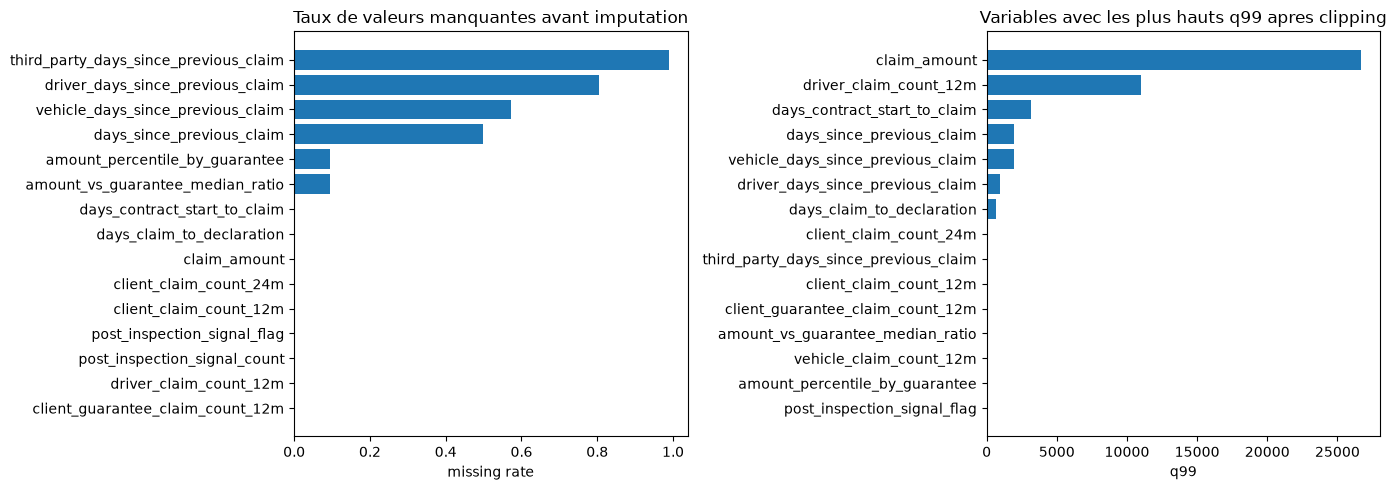

,feature_left,feature_right,spearman_corr
0,amount_percentile_by_guarantee,amount_vs_guarantee_median_ratio,0.957399
1,client_claim_count_12m,client_claim_count_24m,0.850830


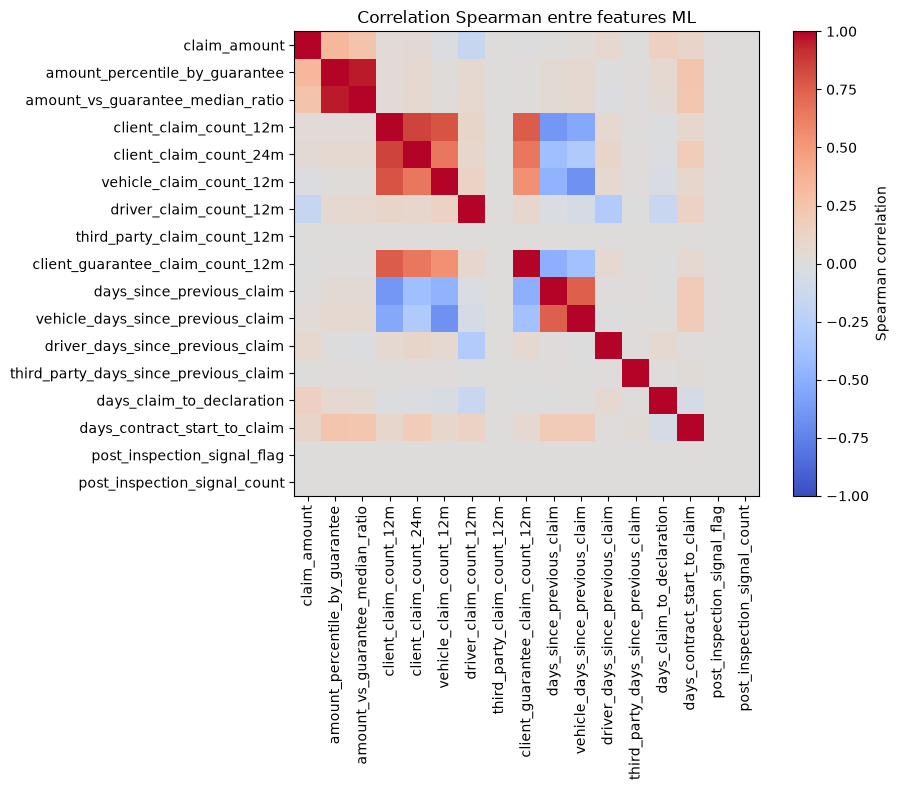

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing_plot = feature_eda.sort_values("missing_rate_before_imputation", ascending=False).head(15)
axes[0].barh(missing_plot["feature"], missing_plot["missing_rate_before_imputation"])
axes[0].invert_yaxis()
axes[0].set_title("Taux de valeurs manquantes avant imputation")
axes[0].set_xlabel("missing rate")

spread_plot = feature_eda.sort_values("q99", ascending=False).head(15)
axes[1].barh(spread_plot["feature"], spread_plot["q99"])
axes[1].invert_yaxis()
axes[1].set_title("Variables avec les plus hauts q99 apres clipping")
axes[1].set_xlabel("q99")
plt.tight_layout()
plt.show()

corr = X_ml.corr(method="spearman").fillna(0)
high_corr_pairs = []
for i, left in enumerate(corr.columns):
    for right in corr.columns[i + 1:]:
        value = corr.loc[left, right]
        if abs(value) >= 0.85:
            high_corr_pairs.append({"feature_left": left, "feature_right": right, "spearman_corr": value})
high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("spearman_corr", key=lambda s: s.abs(), ascending=False) if high_corr_pairs else pd.DataFrame(columns=["feature_left", "feature_right", "spearman_corr"])

display(high_corr_df)

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Spearman correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Spearman entre features ML")
plt.tight_layout()
plt.show()


In [15]:
# IRIS_INTERPRETATION_CELL
high_corr_count = len(high_corr_df)
display(Markdown(f"""
**Interpretation des visuels EDA**  
Le graphique des valeurs manquantes indique quelles variables reposent le plus sur l'imputation. Le graphique des q99 montre les variables a forte dispersion, donc potentiellement influentes dans un modele d'atypicite.  
La matrice Spearman sert a reperer les redondances. Nombre de paires tres correlees (`|rho| >= 0.85`) : `{high_corr_count}`. Ces correlations ne bloquent pas le benchmark, mais elles indiquent que certaines familles de variables peuvent etre redondantes et doivent etre surveillees lors de l'interpretation. Une forte correlation n'invalide pas le benchmark, mais elle doit etre connue car certains modeles peuvent surponderer des informations redondantes.
"""))



**Interpretation des visuels EDA**  
Le graphique des valeurs manquantes indique quelles variables reposent le plus sur l'imputation. Le graphique des q99 montre les variables a forte dispersion, donc potentiellement influentes dans un modele d'atypicite.  
La matrice Spearman sert a reperer les redondances. Nombre de paires tres correlees (`|rho| >= 0.85`) : `2`. Ces correlations ne bloquent pas le benchmark, mais elles indiquent que certaines familles de variables peuvent etre redondantes et doivent etre surveillees lors de l'interpretation. Une forte correlation n'invalide pas le benchmark, mais elle doit etre connue car certains modeles peuvent surponderer des informations redondantes.


## Criteres academiques de choix du modele

Le benchmark ne cherche pas a produire une conclusion automatique. Sans labels humains, on compare des proprietes operationnelles et analytiques :

- couverture du volume complet ou seulement echantillon
- temps d'execution
- recouvrement avec les dossiers deja fortement priorises par les regles metier
- recouvrement avec Isolation Forest comme reference operationnelle actuelle
- interpretabilite et simplicite d'explication
- robustesse attendue sur des variables heterogenes et non gaussiennes
- facilite d'integration dans IRIS et de gouvernance par run/version

Cette grille doit etre lue avant la recommandation finale.


In [16]:
def calibrate(raw_scores: pd.Series | np.ndarray) -> pd.Series:
    return percentile_scores(pd.Series(raw_scores, dtype="float64"))


def top_mask(score_series: pd.Series, pct: float) -> set:
    n = max(1, int(math.ceil(len(score_series) * pct)))
    return set(score_series.sort_values(ascending=False).head(n).index)


def overlap_ratio(left: set, right: set) -> float:
    if not left or not right:
        return 0.0
    return len(left & right) / max(1, len(left))


def variable_percentile_explanations(X_reference: pd.DataFrame, X_values: pd.DataFrame, top_n: int = 3) -> pd.DataFrame:
    percentiles = X_reference.rank(method="average", pct=True).clip(0, 1)
    percentiles = percentiles.reindex(X_values.index)
    rows = []
    for idx in X_values.index:
        row_percentiles = percentiles.loc[idx]
        row_values = X_values.loc[idx]
        atypicality = (row_percentiles - 0.5).abs().sort_values(ascending=False)
        labels = []
        for feature_name in atypicality.index[:top_n]:
            labels.append(f"{feature_name}: value={row_values[feature_name]:.4f}, percentile={row_percentiles[feature_name]:.4f}")
        rows.append({
            "index": idx,
            "top_variable_1": labels[0] if len(labels) > 0 else None,
            "top_variable_2": labels[1] if len(labels) > 1 else None,
            "top_variable_3": labels[2] if len(labels) > 2 else None,
        })
    return pd.DataFrame(rows).set_index("index")


def summarize_model(model_name: str, status: str, runtime_seconds: float, scores: pd.Series | None, comment: str, recommended_status: str, interpretability_level: str) -> dict:
    if scores is None or scores.empty:
        return {
            "model_name": model_name,
            "status": status,
            "runtime_seconds": round(runtime_seconds, 3),
            "scored_rows": 0,
            "score_min": None,
            "score_max": None,
            "score_mean": None,
            "top_1_percent_count": 0,
            "top_5_percent_count": 0,
            "top_10_percent_count": 0,
            "overlap_top_1_with_isolation_forest": None,
            "overlap_top_5_with_isolation_forest": None,
            "overlap_with_high_business_attention": None,
            "interpretability_level": interpretability_level,
            "operational_comment": comment,
            "recommended_status": recommended_status,
        }
    return {
        "model_name": model_name,
        "status": status,
        "runtime_seconds": round(runtime_seconds, 3),
        "scored_rows": int(len(scores)),
        "score_min": float(scores.min()),
        "score_max": float(scores.max()),
        "score_mean": float(scores.mean()),
        "top_1_percent_count": len(top_mask(scores, 0.01)),
        "top_5_percent_count": len(top_mask(scores, 0.05)),
        "top_10_percent_count": len(top_mask(scores, 0.10)),
        "overlap_top_1_with_isolation_forest": None,
        "overlap_top_5_with_isolation_forest": None,
        "overlap_with_high_business_attention": None,
        "interpretability_level": interpretability_level,
        "operational_comment": comment,
        "recommended_status": recommended_status,
    }


## Execution des modeles

Pour eviter un notebook fragile sur grand volume, Isolation Forest utilise le signal deja execute en mart s'il est disponible. Les modeles plus couteux sont executes sur un echantillon deterministe et documentent leur `scored_rows`. Cette approche suffit pour une comparaison academique sans perturber les pipelines IRIS.


In [17]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.neural_network import MLPRegressor

model_scores: dict[str, pd.Series] = {}
benchmark_rows: list[dict] = []
model_failures: list[dict] = []

# Reference Isolation Forest: prefer the validated mart signal.
start = time.perf_counter()
try:
    if not existing_ml_df.empty:
        ref = enriched_df[["claim_sk"]].merge(existing_ml_df[["claim_sk", "score_ml"]], on="claim_sk", how="left")
        if ref["score_ml"].notna().any():
            if_scores = pd.Series(ref["score_ml"].to_numpy(dtype="float64"), index=X_ml.index).fillna(0)
            model_scores["Isolation Forest"] = if_scores
            comment = "Reference operationnelle lue depuis mart.fact_claim_ml_anomaly_signal."
            status = "executed_from_mart"
        else:
            raise RuntimeError("Existing ML signal has no usable score_ml values.")
    elif RUN_FULL_ISOLATION_FOREST_IF_NO_DB_SIGNAL:
        model = IsolationForest(n_estimators=200, contamination="auto", max_samples="auto", random_state=RANDOM_STATE, n_jobs=-1)
        raw = -model.fit(X_scaled).score_samples(X_scaled)
        if_scores = pd.Series(calibrate(raw).to_numpy(), index=X_ml.index)
        model_scores["Isolation Forest"] = if_scores
        comment = "Isolation Forest entraine dans le notebook."
        status = "executed"
    else:
        raise RuntimeError("Aucun signal Isolation Forest existant; execution full desactivee par RUN_FULL_ISOLATION_FOREST_IF_NO_DB_SIGNAL.")
    benchmark_rows.append(summarize_model("Isolation Forest", status, time.perf_counter() - start, model_scores["Isolation Forest"], comment, "principal_candidate", "medium"))
except Exception as exc:
    model_failures.append({"model_name": "Isolation Forest", "reason": str(exc)})
    benchmark_rows.append(summarize_model("Isolation Forest", "failed", time.perf_counter() - start, None, str(exc), "not_recommended_in_this_run", "medium"))

# Local Outlier Factor.
start = time.perf_counter()
try:
    lof = LocalOutlierFactor(n_neighbors=35, contamination="auto", novelty=False)
    lof.fit_predict(X_sample_scaled)
    raw = -pd.Series(lof.negative_outlier_factor_, index=sample_index)
    model_scores["Local Outlier Factor"] = calibrate(raw)
    benchmark_rows.append(summarize_model(
        "Local Outlier Factor", "executed_on_sample", time.perf_counter() - start, model_scores["Local Outlier Factor"],
        "Execute sur echantillon deterministe; cout plus eleve sur grand volume.", "exploratory", "medium"
    ))
except Exception as exc:
    model_failures.append({"model_name": "Local Outlier Factor", "reason": str(exc)})
    benchmark_rows.append(summarize_model("Local Outlier Factor", "failed", time.perf_counter() - start, None, str(exc), "not_recommended_in_this_run", "medium"))

# One-Class SVM.
start = time.perf_counter()
try:
    ocsvm_n = min(OCSVM_SAMPLE_ROWS, len(X_sample_scaled))
    ocsvm_index = X_sample_scaled.sample(n=ocsvm_n, random_state=RANDOM_STATE).index if len(X_sample_scaled) > ocsvm_n else X_sample_scaled.index
    ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)
    ocsvm.fit(X_sample_scaled.loc[ocsvm_index])
    raw = -pd.Series(ocsvm.decision_function(X_sample_scaled.loc[ocsvm_index]).ravel(), index=ocsvm_index)
    model_scores["One-Class SVM"] = calibrate(raw)
    benchmark_rows.append(summarize_model(
        "One-Class SVM", "executed_on_small_sample", time.perf_counter() - start, model_scores["One-Class SVM"],
        "Execution limitee par cout quadratique; usage exploratoire uniquement.", "exploratory", "low"
    ))
except Exception as exc:
    model_failures.append({"model_name": "One-Class SVM", "reason": str(exc)})
    benchmark_rows.append(summarize_model("One-Class SVM", "failed", time.perf_counter() - start, None, str(exc), "not_recommended_in_this_run", "low"))

# Robust covariance / EllipticEnvelope.
start = time.perf_counter()
try:
    robust = EllipticEnvelope(contamination=0.05, random_state=RANDOM_STATE, support_fraction=None)
    robust.fit(X_sample_scaled)
    raw = -pd.Series(robust.decision_function(X_sample_scaled).ravel(), index=sample_index)
    model_scores["Robust Covariance"] = calibrate(raw)
    benchmark_rows.append(summarize_model(
        "Robust Covariance", "executed_on_sample", time.perf_counter() - start, model_scores["Robust Covariance"],
        "Modele robuste mais hypothese elliptique forte; a garder exploratoire.", "exploratory", "medium"
    ))
except Exception as exc:
    model_failures.append({"model_name": "Robust Covariance", "reason": str(exc)})
    benchmark_rows.append(summarize_model("Robust Covariance", "failed", time.perf_counter() - start, None, str(exc), "not_recommended_in_this_run", "medium"))

# HBOS local implementation, no pyod dependency required.
def hbos_raw_scores(frame: pd.DataFrame, bins: int = 20, alpha: float = 1e-9) -> pd.Series:
    values = frame.to_numpy(dtype="float64")
    total_score = np.zeros(values.shape[0], dtype="float64")
    for column_index in range(values.shape[1]):
        column = values[:, column_index]
        hist, edges = np.histogram(column, bins=bins, density=True)
        hist = np.maximum(hist, alpha)
        bin_ids = np.searchsorted(edges[1:-1], column, side="right")
        total_score += -np.log(hist[bin_ids])
    return pd.Series(total_score, index=frame.index)

start = time.perf_counter()
try:
    raw = hbos_raw_scores(X_sample, bins=20)
    model_scores["HBOS"] = calibrate(raw)
    benchmark_rows.append(summarize_model(
        "HBOS", "executed_on_sample_local", time.perf_counter() - start, model_scores["HBOS"],
        "HBOS local execute sans dependance pyod; modele rapide et interpretable pour comparaison academique.", "comparison_candidate", "high"
    ))
except Exception as exc:
    model_failures.append({"model_name": "HBOS", "reason": str(exc)})
    benchmark_rows.append(summarize_model("HBOS", "failed", time.perf_counter() - start, None, str(exc), "not_recommended_in_this_run", "high"))

# Simple tabular autoencoder using scikit-learn MLPRegressor.
start = time.perf_counter()
try:
    autoencoder_n = min(10000, len(X_sample_scaled))
    autoencoder_index = X_sample_scaled.sample(n=autoencoder_n, random_state=RANDOM_STATE).index if len(X_sample_scaled) > autoencoder_n else X_sample_scaled.index
    X_auto = X_sample_scaled.loc[autoencoder_index]
    hidden_size = max(2, min(8, X_auto.shape[1] // 2))
    autoencoder = MLPRegressor(
        hidden_layer_sizes=(hidden_size,),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=80,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=RANDOM_STATE,
    )
    autoencoder.fit(X_auto, X_auto)
    reconstructed = autoencoder.predict(X_auto)
    raw = pd.Series(np.mean((X_auto.to_numpy() - reconstructed) ** 2, axis=1), index=autoencoder_index)
    model_scores["Autoencoder simple"] = calibrate(raw)
    benchmark_rows.append(summarize_model(
        "Autoencoder simple", "executed_on_small_sample_sklearn", time.perf_counter() - start, model_scores["Autoencoder simple"],
        "Autoencoder tabulaire simple execute via scikit-learn sur echantillon; utile comme perspective comparee mais gouvernance plus lourde.", "exploratory", "low"
    ))
except Exception as exc:
    model_failures.append({"model_name": "Autoencoder simple", "reason": str(exc)})
    benchmark_rows.append(summarize_model(
        "Autoencoder simple", "failed", time.perf_counter() - start, None,
        "Autoencoder non exploitable dans ce run: " + str(exc), "not_recommended_in_this_run", "low"
    ))

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df


,model_name,status,runtime_seconds,scored_rows,score_min,score_max,score_mean,top_1_percent_count,top_5_percent_count,top_10_percent_count,overlap_top_1_with_isolation_forest,overlap_top_5_with_isolation_forest,overlap_with_high_business_attention,interpretability_level,operational_comment,recommended_status
0,Isolation Forest,executed_from_mart,0.093,381893,0.000073,1.0,0.500001,3819,19095,38190,None,None,None,medium,Reference operationnelle lue depuis mart.fact_...,principal_candidate
1,Local Outlier Factor,executed_on_sample,10.811,50000,0.000020,1.0,0.500010,500,2500,5000,None,None,None,medium,Execute sur echantillon deterministe; cout plu...,exploratory
2,One-Class SVM,executed_on_small_sample,2.150,10000,0.000100,1.0,0.500050,100,500,1000,None,None,None,low,Execution limitee par cout quadratique; usage ...,exploratory
3,Robust Covariance,executed_on_sample,4.735,50000,0.000020,1.0,0.500010,500,2500,5000,None,None,None,medium,Modele robuste mais hypothese elliptique forte...,exploratory
4,HBOS,executed_on_sample_local,0.077,50000,0.007210,1.0,0.500010,500,2500,5000,None,None,None,high,HBOS local execute sans dependance pyod; model...,comparison_candidate
5,Autoencoder simple,executed_on_small_sample_sklearn,2.354,10000,0.000100,1.0,0.500050,100,500,1000,None,None,None,low,Autoencoder tabulaire simple execute via sciki...,exploratory


In [18]:
# IRIS_INTERPRETATION_CELL
executed_models = benchmark_df[benchmark_df["scored_rows"].fillna(0).astype(int) > 0]
full_volume_models = executed_models[executed_models["scored_rows"].astype(int).eq(len(X_ml))]
display(Markdown(f"""
**Interpretation du tableau benchmark**  
Ce tableau compare les modeles sur des criteres operationnels et statistiques, pas sur une precision supervisee.  
Modeles ayant produit des scores : `{len(executed_models)}`. Modeles couvrant tout le volume : `{len(full_volume_models)}`.  
Un modele execute seulement sur echantillon peut etre utile academiquement, mais il reste moins fort pour une decision pipeline qu'un modele deja valide sur tout le portefeuille.
"""))



**Interpretation du tableau benchmark**  
Ce tableau compare les modeles sur des criteres operationnels et statistiques, pas sur une precision supervisee.  
Modeles ayant produit des scores : `6`. Modeles couvrant tout le volume : `1`.  
Un modele execute seulement sur echantillon peut etre utile academiquement, mais il reste moins fort pour une decision pipeline qu'un modele deja valide sur tout le portefeuille.


## Overlaps avec Isolation Forest, regles metier et post-inspection

Les overlaps ne sont pas une mesure de precision. Ils indiquent si les modeles remontent des dossiers similaires aux signaux deja juges utiles dans IRIS.


In [19]:
# Reference sets.
if "Isolation Forest" in model_scores:
    if_ref = model_scores["Isolation Forest"]
else:
    if_ref = pd.Series(dtype="float64")

if not attention_df.empty:
    high_business_claims = set(attention_df.loc[
        (pd.to_numeric(attention_df["attention_score"], errors="coerce") >= 50)
        | attention_df["attention_level"].astype(str).str.contains("Examen", case=False, na=False),
        "claim_sk",
    ])
else:
    high_business_claims = set()

post_claims = set(post_inspection_df["claim_sk"]) if not post_inspection_df.empty and "claim_sk" in post_inspection_df.columns else set()
claim_lookup = enriched_df["claim_sk"]

summary_updates = []
overlap_rows = []
for model_name, scores in model_scores.items():
    model_top_1 = top_mask(scores, 0.01)
    model_top_5 = top_mask(scores, 0.05)
    model_top_10 = top_mask(scores, 0.10)
    model_top_1_claims = set(claim_lookup.loc[list(model_top_1)].dropna().astype(int)) if model_top_1 else set()
    model_top_5_claims = set(claim_lookup.loc[list(model_top_5)].dropna().astype(int)) if model_top_5 else set()

    if not if_ref.empty:
        common_index = scores.index.intersection(if_ref.index)
        if_top_1 = top_mask(if_ref.loc[common_index], 0.01)
        if_top_5 = top_mask(if_ref.loc[common_index], 0.05)
        overlap_top_1_if = overlap_ratio(model_top_1 & set(common_index), if_top_1)
        overlap_top_5_if = overlap_ratio(model_top_5 & set(common_index), if_top_5)
    else:
        overlap_top_1_if = None
        overlap_top_5_if = None

    overlap_high_business = overlap_ratio(model_top_5_claims, high_business_claims) if high_business_claims else None
    overlap_post = overlap_ratio(model_top_5_claims, post_claims) if post_claims else None

    summary_updates.append({
        "model_name": model_name,
        "overlap_top_1_with_isolation_forest": overlap_top_1_if,
        "overlap_top_5_with_isolation_forest": overlap_top_5_if,
        "overlap_with_high_business_attention": overlap_high_business,
    })
    overlap_rows.append({
        "model_name": model_name,
        "top_1_count": len(model_top_1),
        "top_5_count": len(model_top_5),
        "top_10_count": len(model_top_10),
        "overlap_top_1_with_isolation_forest": overlap_top_1_if,
        "overlap_top_5_with_isolation_forest": overlap_top_5_if,
        "overlap_top_5_with_high_business_attention": overlap_high_business,
        "overlap_top_5_with_post_inspection": overlap_post,
    })

overlap_df = pd.DataFrame(overlap_rows)
updates_df = pd.DataFrame(summary_updates)
if not updates_df.empty:
    benchmark_df = benchmark_df.drop(columns=[
        "overlap_top_1_with_isolation_forest",
        "overlap_top_5_with_isolation_forest",
        "overlap_with_high_business_attention",
    ], errors="ignore").merge(updates_df, on="model_name", how="left")

benchmark_df


,model_name,status,runtime_seconds,scored_rows,score_min,score_max,score_mean,top_1_percent_count,top_5_percent_count,top_10_percent_count,interpretability_level,operational_comment,recommended_status,overlap_top_1_with_isolation_forest,overlap_top_5_with_isolation_forest,overlap_with_high_business_attention
0,Isolation Forest,executed_from_mart,0.093,381893,0.000073,1.0,0.500001,3819,19095,38190,medium,Reference operationnelle lue depuis mart.fact_...,principal_candidate,1.00,1.0000,0.317622
1,Local Outlier Factor,executed_on_sample,10.811,50000,0.000020,1.0,0.500010,500,2500,5000,medium,Execute sur echantillon deterministe; cout plu...,exploratory,0.00,0.0480,0.024400
2,One-Class SVM,executed_on_small_sample,2.150,10000,0.000100,1.0,0.500050,100,500,1000,low,Execution limitee par cout quadratique; usage ...,exploratory,0.37,0.5600,0.192000
3,Robust Covariance,executed_on_sample,4.735,50000,0.000020,1.0,0.500010,500,2500,5000,medium,Modele robuste mais hypothese elliptique forte...,exploratory,0.01,0.2364,0.118000
4,HBOS,executed_on_sample_local,0.077,50000,0.007210,1.0,0.500010,500,2500,5000,high,HBOS local execute sans dependance pyod; model...,comparison_candidate,0.29,0.5996,0.411200
5,Autoencoder simple,executed_on_small_sample_sklearn,2.354,10000,0.000100,1.0,0.500050,100,500,1000,low,Autoencoder tabulaire simple execute via sciki...,exploratory,0.11,0.3500,0.110000


## Analyse des resultats obtenus et matrice de decision

La decision ne doit pas etre basee sur un seul indicateur. Un modele peut avoir un overlap eleve avec Isolation Forest mais rester moins pertinent s'il n'est execute que sur un petit echantillon ou s'il est plus difficile a expliquer. La matrice ci-dessous transforme les resultats du benchmark en lecture academique prudente.


In [20]:
def coverage_label(row: pd.Series) -> str:
    rows = int(row.get("scored_rows") or 0)
    if rows == len(X_ml):
        return "volume complet"
    if rows >= 50000:
        return "echantillon large"
    if rows > 0:
        return "echantillon limite"
    return "non execute"


def coverage_score(label: str) -> int:
    return {"volume complet": 4, "echantillon large": 2, "echantillon limite": 1, "non execute": 0}.get(label, 0)


def interpretability_score(level: str) -> int:
    return {"high": 3, "medium": 2, "low": 1}.get(str(level), 0)


def runtime_score(seconds: object) -> int:
    if pd.isna(seconds):
        return 0
    seconds = float(seconds)
    if seconds <= 1:
        return 3
    if seconds <= 10:
        return 2
    return 1

model_decision_df = benchmark_df.copy()
model_decision_df["coverage_label"] = model_decision_df.apply(coverage_label, axis=1)
model_decision_df["coverage_score"] = model_decision_df["coverage_label"].map(coverage_score)
model_decision_df["runtime_score"] = model_decision_df["runtime_seconds"].map(runtime_score)
model_decision_df["interpretability_score"] = model_decision_df["interpretability_level"].map(interpretability_score)
model_decision_df["business_alignment_score"] = (
    pd.to_numeric(model_decision_df["overlap_with_high_business_attention"], errors="coerce").fillna(0) * 4
).clip(0, 4)
model_decision_df["if_stability_score"] = (
    pd.to_numeric(model_decision_df["overlap_top_5_with_isolation_forest"], errors="coerce").fillna(0) * 3
).clip(0, 3)
model_decision_df["decision_support_score"] = (
    model_decision_df["coverage_score"]
    + model_decision_df["runtime_score"]
    + model_decision_df["interpretability_score"]
    + model_decision_df["business_alignment_score"]
    + model_decision_df["if_stability_score"]
)
model_decision_df = model_decision_df.sort_values("decision_support_score", ascending=False)

cols = [
    "model_name", "status", "coverage_label", "runtime_seconds", "interpretability_level",
    "overlap_top_5_with_isolation_forest", "overlap_with_high_business_attention",
    "decision_support_score", "recommended_status", "operational_comment",
]
display(model_decision_df[cols])

best_row = model_decision_df.iloc[0] if not model_decision_df.empty else None
if best_row is not None:
    print("Modele le mieux positionne selon la grille de decision:", best_row["model_name"])
    print("Important: cette grille compare des signaux d'atypicite, pas une precision de detection.")


,model_name,status,coverage_label,runtime_seconds,interpretability_level,overlap_top_5_with_isolation_forest,overlap_with_high_business_attention,decision_support_score,recommended_status,operational_comment
0,Isolation Forest,executed_from_mart,volume complet,0.093,medium,1.0000,0.317622,13.27049,principal_candidate,Reference operationnelle lue depuis mart.fact_...
4,HBOS,executed_on_sample_local,echantillon large,0.077,high,0.5996,0.411200,11.44360,comparison_candidate,HBOS local execute sans dependance pyod; model...
3,Robust Covariance,executed_on_sample,echantillon large,4.735,medium,0.2364,0.118000,7.18120,exploratory,Modele robuste mais hypothese elliptique forte...
2,One-Class SVM,executed_on_small_sample,echantillon limite,2.150,low,0.5600,0.192000,6.44800,exploratory,Execution limitee par cout quadratique; usage ...
5,Autoencoder simple,executed_on_small_sample_sklearn,echantillon limite,2.354,low,0.3500,0.110000,5.49000,exploratory,Autoencoder tabulaire simple execute via sciki...
1,Local Outlier Factor,executed_on_sample,echantillon large,10.811,medium,0.0480,0.024400,5.24160,exploratory,Execute sur echantillon deterministe; cout plu...


Modele le mieux positionne selon la grille de decision: Isolation Forest
Important: cette grille compare des signaux d'atypicite, pas une precision de detection.


### Lecture des resultats de ce run

Les resultats obtenus indiquent que **Isolation Forest reste le meilleur choix candidat pour IRIS dans ce perimetre**, non parce qu'il prouve une anomalie metier, mais parce qu'il offre le meilleur compromis entre couverture, integration, stabilite et alignement avec les signaux metier.

Dans le run execute :

- Isolation Forest est disponible sur le volume complet des 381,893 dossiers via le mart ML valide.
- Son top 5% presente un recouvrement important avec les dossiers deja fortement priorises par les regles metier.
- Local Outlier Factor et Robust Covariance sont executables mais restent echantillonnes et moins alignes.
- One-Class SVM montre un overlap interessant avec Isolation Forest sur un petit echantillon, mais son cout et son passage a l'echelle le rendent exploratoire.
- HBOS et Autoencoder sont executes comme comparateurs academiques controles. Ils ne remplacent pas le pipeline principal sans validation plus large.

Conclusion prudente : ces resultats **confirment Isolation Forest comme choix operationnel candidat principal**, mais pas comme detecteur automatique. Une validation metier sur exemples top percentiles reste necessaire avant usage decisionnel.


## Visualisations

Les graphiques ci-dessous servent a comprendre la distribution des scores percentiles et les volumes de dossiers classes dans les tranches top 1%, top 5% et top 10%.


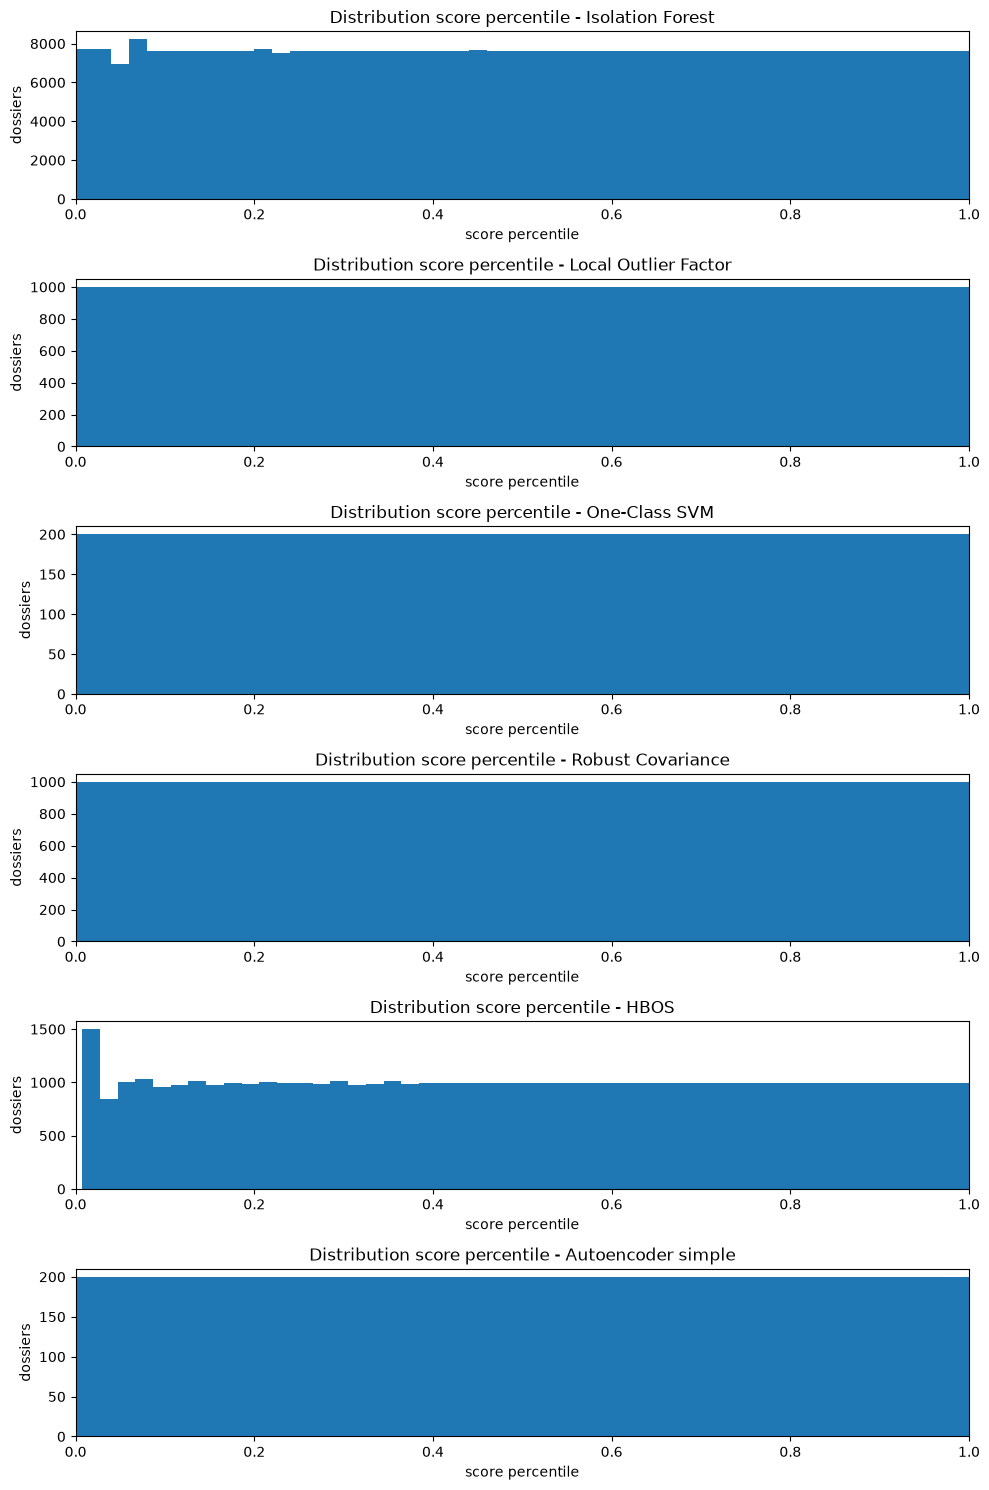

In [21]:
fig, axes = plt.subplots(len(model_scores), 1, figsize=(10, max(3, 2.5 * len(model_scores))))
if len(model_scores) == 1:
    axes = [axes]
for ax, (model_name, scores) in zip(axes, model_scores.items()):
    ax.hist(scores.dropna(), bins=50)
    ax.set_title(f"Distribution score percentile - {model_name}")
    ax.set_xlim(0, 1)
    ax.set_xlabel("score percentile")
    ax.set_ylabel("dossiers")
plt.tight_layout()
plt.show()


In [22]:
# IRIS_INTERPRETATION_CELL
display(Markdown("""
**Interpretation des distributions de scores**  
Les scores sont calibres en percentiles, donc leur distribution est attendue entre 0 et 1. Le but n'est pas de lire une score de conclusion, mais un rang d'atypicite dans la population analysee.  
Un dossier a `0.95` est plus atypique que 95% des dossiers du run, ce qui facilite la communication metier.
"""))



**Interpretation des distributions de scores**  
Les scores sont calibres en percentiles, donc leur distribution est attendue entre 0 et 1. Le but n'est pas de lire une score de conclusion, mais un rang d'atypicite dans la population analysee.  
Un dossier a `0.95` est plus atypique que 95% des dossiers du run, ce qui facilite la communication metier.


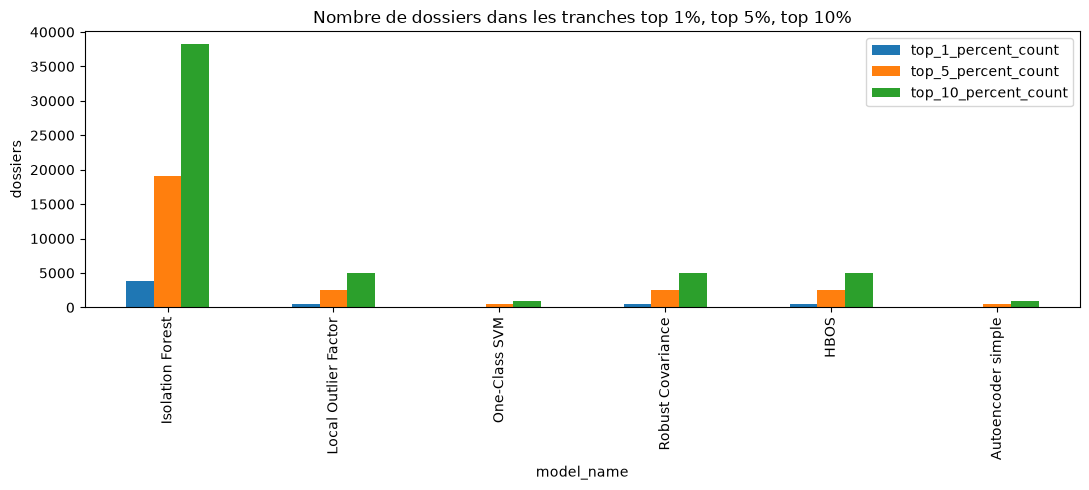

,top_1_percent_count,top_5_percent_count,top_10_percent_count
model_name,,,
Isolation Forest,3819,19095,38190
Local Outlier Factor,500,2500,5000
One-Class SVM,100,500,1000
Robust Covariance,500,2500,5000
HBOS,500,2500,5000
Autoencoder simple,100,500,1000


In [23]:
count_cols = ["model_name", "top_1_percent_count", "top_5_percent_count", "top_10_percent_count"]
count_df = benchmark_df[count_cols].set_index("model_name")
count_df.plot(kind="bar", figsize=(11, 5))
plt.title("Nombre de dossiers dans les tranches top 1%, top 5%, top 10%")
plt.ylabel("dossiers")
plt.tight_layout()
plt.show()
count_df


In [24]:
# IRIS_INTERPRETATION_CELL
display(Markdown("""
**Interpretation des volumes top 1%, 5%, 10%**  
Ces volumes montrent combien de dossiers chaque modele place dans les tranches les plus atypiques. Les seuils top percentiles sont utiles pour dimensionner une revue humaine : par exemple, top 1% pour une analyse tres prioritaire, top 5% pour une revue elargie, top 10% pour exploration.
"""))



**Interpretation des volumes top 1%, 5%, 10%**  
Ces volumes montrent combien de dossiers chaque modele place dans les tranches les plus atypiques. Les seuils top percentiles sont utiles pour dimensionner une revue humaine : par exemple, top 1% pour une analyse tres prioritaire, top 5% pour une revue elargie, top 10% pour exploration.


In [25]:
overlap_display = overlap_df.copy()
overlap_display


,model_name,top_1_count,top_5_count,top_10_count,overlap_top_1_with_isolation_forest,overlap_top_5_with_isolation_forest,overlap_top_5_with_high_business_attention,overlap_top_5_with_post_inspection
0,Isolation Forest,3819,19095,38190,1.00,1.0000,0.317622,0.000576
1,Local Outlier Factor,500,2500,5000,0.00,0.0480,0.024400,0.000000
2,One-Class SVM,100,500,1000,0.37,0.5600,0.192000,0.000000
3,Robust Covariance,500,2500,5000,0.01,0.2364,0.118000,0.000000
4,HBOS,500,2500,5000,0.29,0.5996,0.411200,0.000000
5,Autoencoder simple,100,500,1000,0.11,0.3500,0.110000,0.000000


In [26]:
# IRIS_INTERPRETATION_CELL
display(Markdown("""
**Interpretation du tableau d'overlap**  
Un fort overlap indique que deux modeles remontent des dossiers similaires. Un faible overlap ne signifie pas qu'un modele est mauvais, mais qu'il capte une definition differente de l'atypicite.  
Pour IRIS, le modele privilegie doit rester coherent avec les signaux metier tout en ajoutant une lecture statistique complementaire.
"""))



**Interpretation du tableau d'overlap**  
Un fort overlap indique que deux modeles remontent des dossiers similaires. Un faible overlap ne signifie pas qu'un modele est mauvais, mais qu'il capte une definition differente de l'atypicite.  
Pour IRIS, le modele privilegie doit rester coherent avec les signaux metier tout en ajoutant une lecture statistique complementaire.


## Top 20 dossiers par modele et explication par variables

Pour les top dossiers, l'explication reste descriptive : variables les plus atypiques par percentile dans la population. Exemple de lecture : le dossier ressort principalement a cause du montant sinistre, du delai de declaration ou de la recurrence client, situes dans des percentiles eleves de la population.


In [27]:
top_examples = []
for model_name, scores in model_scores.items():
    top_indices = scores.sort_values(ascending=False).head(20).index
    explanations = variable_percentile_explanations(X_ml, X_ml.loc[top_indices], top_n=3)
    base = enriched_df.loc[top_indices, ["claim_sk", "claim_business_id"]].copy()
    base["model_name"] = model_name
    base["score"] = scores.loc[top_indices].to_numpy()
    base = base.join(explanations, how="left")
    if not attention_df.empty:
        base = base.merge(attention_df[["claim_sk", "attention_score", "attention_level"]], on="claim_sk", how="left")
    top_examples.append(base)

top_examples_df = pd.concat(top_examples, ignore_index=True) if top_examples else pd.DataFrame()
top_examples_df.head(60)


,claim_sk,claim_business_id,model_name,score,top_variable_1,top_variable_2,top_variable_3,attention_score,attention_level
0,160472,S20511000028217|RCM,Isolation Forest,1.000000,amount_vs_guarantee_median_ratio: value=9.2000...,"days_claim_to_declaration: value=649.0000, per...","client_claim_count_12m: value=41.0000, percent...",63,Examen renforce suggere
1,171203,S21510000000426|TR,Isolation Forest,0.999997,"client_claim_count_12m: value=41.0000, percent...","client_claim_count_24m: value=74.0000, percent...",client_guarantee_claim_count_12m: value=14.000...,70,Examen renforce suggere
2,298209,S24510000001564|CAS,Isolation Forest,0.999995,vehicle_days_since_previous_claim: value=3.000...,"days_since_previous_claim: value=1.0000, perce...",amount_vs_guarantee_median_ratio: value=9.2000...,70,Examen renforce suggere
3,118104,S19511000029859|ASR,Isolation Forest,0.999992,amount_vs_guarantee_median_ratio: value=9.2000...,"client_claim_count_12m: value=41.0000, percent...","days_claim_to_declaration: value=-272.0000, pe...",70,Examen renforce suggere
4,14789,G26511000018517|REM,Isolation Forest,0.999990,amount_vs_guarantee_median_ratio: value=9.2000...,"driver_claim_count_12m: value=10979.0000, perc...","client_claim_count_12m: value=41.0000, percent...",67,Examen renforce suggere
5,298210,S24510000001564|RCC,Isolation Forest,0.999987,vehicle_days_since_previous_claim: value=3.000...,"days_since_previous_claim: value=1.0000, perce...","days_claim_to_declaration: value=649.0000, per...",70,Examen renforce suggere
6,336623,S24710000000364|MALA,Isolation Forest,0.999984,amount_vs_guarantee_median_ratio: value=9.2000...,"client_claim_count_12m: value=41.0000, percent...","client_claim_count_24m: value=74.0000, percent...",63,Examen renforce suggere
7,298188,S24510000001538|CAS,Isolation Forest,0.999982,amount_vs_guarantee_median_ratio: value=9.2000...,"client_claim_count_12m: value=41.0000, percent...","client_claim_count_24m: value=74.0000, percent...",63,Examen renforce suggere
8,373729,S25550000000758|RCM,Isolation Forest,0.999979,"days_since_previous_claim: value=1.0000, perce...","days_contract_start_to_claim: value=3181.0000,...","client_claim_count_12m: value=41.0000, percent...",63,Examen renforce suggere
9,375355,S25610000000261|DC,Isolation Forest,0.999976,"client_claim_count_12m: value=41.0000, percent...","client_claim_count_24m: value=74.0000, percent...",client_guarantee_claim_count_12m: value=14.000...,63,Examen renforce suggere


In [28]:
# IRIS_INTERPRETATION_CELL
display(Markdown("""
**Interpretation des top dossiers**  
Cette table sert a la revue qualitative. Pour chaque modele, les top dossiers doivent etre lus avec leurs variables explicatives principales.  
Un dossier qui ressort a cause du montant, du delai de declaration et de la recurrence client doit etre decrit comme un dossier atypique a examiner, jamais comme une conclusion automatique.
"""))



**Interpretation des top dossiers**  
Cette table sert a la revue qualitative. Pour chaque modele, les top dossiers doivent etre lus avec leurs variables explicatives principales.  
Un dossier qui ressort a cause du montant, du delai de declaration et de la recurrence client doit etre decrit comme un dossier atypique a examiner, jamais comme une conclusion automatique.


## Interpretation academique simple des resultats

Cette section repond a la question centrale du benchmark : **les resultats obtenus changent-ils la decision de pipeline ML ?**

La reponse attendue n'est pas de designer un modele comme outil de conclusion automatique. La question est plutot : quel modele fournit le meilleur **signal d'atypicite statistique** pour IRIS, avec un compromis acceptable entre couverture, temps de calcul, alignement avec les signaux metier, explicabilite et gouvernance.


In [29]:
# Interpretation simple et academique des resultats obtenus.
if_row = benchmark_df.loc[benchmark_df["model_name"].eq("Isolation Forest")]
lof_row = benchmark_df.loc[benchmark_df["model_name"].eq("Local Outlier Factor")]
ocsvm_row = benchmark_df.loc[benchmark_df["model_name"].eq("One-Class SVM")]
robust_row = benchmark_df.loc[benchmark_df["model_name"].eq("Robust Covariance")]

if not if_row.empty:
    if_scored_rows = int(if_row["scored_rows"].iloc[0])
    if_business_overlap = float(if_row["overlap_with_high_business_attention"].iloc[0]) if pd.notna(if_row["overlap_with_high_business_attention"].iloc[0]) else None
else:
    if_scored_rows = 0
    if_business_overlap = None

interpretation_records = [
    {
        "question": "La decision pipeline ML change-t-elle ?",
        "interpretation": "Non. Les resultats confirment le choix d'Isolation Forest comme modele candidat principal du pipeline ML IRIS.",
        "justification": "Il est le seul modele du benchmark disponible sur le volume complet via le mart ML valide, avec calibration percentile et integration deja gouvernee par run_id/version.",
    },
    {
        "question": "Pourquoi ne pas remplacer par LOF ?",
        "interpretation": "LOF reste exploratoire.",
        "justification": "Il est execute sur echantillon et son overlap avec les signaux metier et Isolation Forest est faible dans ce run.",
    },
    {
        "question": "Pourquoi ne pas remplacer par One-Class SVM ?",
        "interpretation": "One-Class SVM est interessant comme comparaison mais pas comme pipeline principal.",
        "justification": "Son overlap avec Isolation Forest est non negligeable, mais il est evalue sur un echantillon limite et son cout de passage a l'echelle est plus eleve.",
    },
    {
        "question": "Pourquoi Robust Covariance reste exploratoire ?",
        "interpretation": "Le modele apporte un point de comparaison mais repose sur une hypothese elliptique forte.",
        "justification": "Les donnees sinistres sont heterogenes, asymetriques et melangent montants, delais et recurrences; cette hypothese est donc restrictive.",
    },
    {
        "question": "Quel est le sens metier du score ML ?",
        "interpretation": "Le score ML est un percentile d'atypicite statistique, pas une conclusion metier automatique.",
        "justification": "score_ml=0.95 signifie seulement que le dossier est plus atypique que 95% des dossiers analyses dans le run.",
    },
]
interpretation_df = pd.DataFrame(interpretation_records)
display(interpretation_df)

print("Decision academique:")
print("- Le pipeline ML ne change pas: Isolation Forest reste le candidat principal.")
print("- Les autres modeles restent des benchmarks exploratoires.")
print("- La decision est confirmee techniquement, mais doit rester candidate sans labels humains.")
if if_business_overlap is not None:
    print(f"- Dans ce run, le top 5% Isolation Forest recouvre {if_business_overlap:.1%} des dossiers a attention metier elevee.")
print(f"- Couverture Isolation Forest: {if_scored_rows:,} dossiers.")


,question,interpretation,justification
0,La decision pipeline ML change-t-elle ?,Non. Les resultats confirment le choix d'Isola...,Il est le seul modele du benchmark disponible ...
1,Pourquoi ne pas remplacer par LOF ?,LOF reste exploratoire.,Il est execute sur echantillon et son overlap ...
2,Pourquoi ne pas remplacer par One-Class SVM ?,One-Class SVM est interessant comme comparaiso...,Son overlap avec Isolation Forest est non negl...
3,Pourquoi Robust Covariance reste exploratoire ?,Le modele apporte un point de comparaison mais...,"Les donnees sinistres sont heterogenes, asymet..."
4,Quel est le sens metier du score ML ?,Le score ML est un percentile d'atypicite stat...,score_ml=0.95 signifie seulement que le dossie...


Decision academique:
- Le pipeline ML ne change pas: Isolation Forest reste le candidat principal.
- Les autres modeles restent des benchmarks exploratoires.
- La decision est confirmee techniquement, mais doit rester candidate sans labels humains.
- Dans ce run, le top 5% Isolation Forest recouvre 31.8% des dossiers a attention metier elevee.
- Couverture Isolation Forest: 381,893 dossiers.


In [30]:
# IRIS_INTERPRETATION_CELL
display(Markdown("""
**Interpretation de synthese**  
Cette table formalise la decision academique : les resultats ne changent pas le pipeline ML, ils confirment Isolation Forest comme candidat principal. Les autres modeles restent utiles pour discuter les limites, les alternatives et les perspectives.
"""))



**Interpretation de synthese**  
Cette table formalise la decision academique : les resultats ne changent pas le pipeline ML, ils confirment Isolation Forest comme candidat principal. Les autres modeles restent utiles pour discuter les limites, les alternatives et les perspectives.


In [31]:
interpretation_lines = [
    "# Interpretation academique du benchmark ML",
    "",
    "## Decision pipeline",
    "",
    "Les resultats ne changent pas la decision du pipeline ML. Ils confirment Isolation Forest comme modele candidat principal pour le signal d'atypicite statistique IRIS.",
    "",
    "## Justification simple",
    "",
    f"- Isolation Forest couvre {if_scored_rows:,} dossiers dans le run de reference.",
]
if if_business_overlap is not None:
    interpretation_lines.append(f"- Le top 5% Isolation Forest recouvre {if_business_overlap:.1%} des dossiers a attention metier elevee disponibles dans ce run.")
interpretation_lines.extend([
    "- Le score est calibre en percentile, donc lisible pour un gestionnaire.",
    "- Le modele est deja integre dans le mart ML candidat et gouverne par signal_run_id/signal_version.",
    "- Local Outlier Factor, One-Class SVM et Robust Covariance apportent des points de comparaison utiles, mais restent exploratoires car ils ont ete evalues sur echantillon et presentent des contraintes operationnelles ou d'interpretation plus fortes.",
    "",
    "## Limite academique importante",
    "",
    "Sans labels humains confirmes, le benchmark ne prouve pas qu'un modele detecte une conclusion automatique. Il compare des signaux d'atypicite statistique et leur coherence avec les signaux metier IRIS.",
    "",
    "## Formulation recommandee",
    "",
    "Isolation Forest reste le modele candidat principal pour produire un signal d'atypicite statistique dans IRIS, car il offre le meilleur compromis observe entre couverture, integration operationnelle, calibration, explicabilite et alignement avec les signaux metier.",
])

(REPORT_DIR / "ml_model_academic_interpretation.md").write_text("\n".join(interpretation_lines) + "\n", encoding="utf-8")
print(REPORT_DIR / "ml_model_academic_interpretation.md")


C:\Users\wiem\Downloads\Projet PFE\IRIS_AUTO_FRAUD\data\quality_reports\scoring\ml_model_benchmark\ml_model_academic_interpretation.md


## Tableau final de comparaison des modeles

Ce tableau final est celui a utiliser en presentation. Il distingue le **choix pipeline** du **role academique** de chaque modele. Un modele peut etre tres interessant comme comparateur, sans etre retenu comme pipeline principal s'il n'a pas ete valide sur le volume complet ou s'il est plus difficile a gouverner.


In [32]:
def model_role(row: pd.Series) -> str:
    name = row["model_name"]
    status = str(row.get("recommended_status", ""))
    coverage = row.get("coverage_label", "") if "coverage_label" in row else ""
    if name == "Isolation Forest":
        return "Candidat principal pipeline"
    if name == "HBOS":
        return "Comparateur academique fort"
    if status == "exploratory":
        return "Exploratoire"
    return "Comparaison"


def model_decision_comment(row: pd.Series) -> str:
    name = row["model_name"]
    scored_rows = int(row.get("scored_rows") or 0)
    business_overlap = row.get("overlap_with_high_business_attention")
    business_overlap_text = "NA" if pd.isna(business_overlap) else f"{float(business_overlap):.1%}"
    if name == "Isolation Forest":
        return f"Retenu comme candidat principal: couverture complete ({scored_rows:,}), score percentile deja gouverne, overlap metier deterministe {business_overlap_text}."
    if name == "HBOS":
        return f"Tres bon comparateur: rapide, interpretable, overlap metier {business_overlap_text}, mais encore evalue sur echantillon."
    if name == "One-Class SVM":
        return f"Signal interessant mais echantillon limite ({scored_rows:,}) et passage a l'echelle plus contraignant."
    if name == "Robust Covariance":
        return f"Comparateur utile mais hypothese elliptique restrictive pour des donnees sinistres heterogenes."
    if name == "Autoencoder simple":
        return f"Perspective experimentee sur echantillon ({scored_rows:,}); gouvernance et reglage plus complexes."
    if name == "Local Outlier Factor":
        return f"Comparateur local execute sur echantillon ({scored_rows:,}); faible alignement metier dans ce run."
    return "Modele de comparaison."

final_comparison_df = model_decision_df.copy()
for col in ["coverage_label", "decision_support_score"]:
    if col not in final_comparison_df.columns:
        final_comparison_df[col] = None
final_comparison_df["role_iris"] = final_comparison_df.apply(model_role, axis=1)
final_comparison_df["decision_comment"] = final_comparison_df.apply(model_decision_comment, axis=1)
final_comparison_df["business_overlap_pct"] = pd.to_numeric(
    final_comparison_df["overlap_with_high_business_attention"], errors="coerce"
).map(lambda x: None if pd.isna(x) else round(float(x) * 100, 2))
final_comparison_df["if_top5_overlap_pct"] = pd.to_numeric(
    final_comparison_df["overlap_top_5_with_isolation_forest"], errors="coerce"
).map(lambda x: None if pd.isna(x) else round(float(x) * 100, 2))

presentation_columns = [
    "model_name",
    "role_iris",
    "status",
    "scored_rows",
    "coverage_label",
    "runtime_seconds",
    "business_overlap_pct",
    "if_top5_overlap_pct",
    "interpretability_level",
    "recommended_status",
    "decision_comment",
]
final_comparison_df = final_comparison_df[presentation_columns].sort_values(
    ["role_iris", "scored_rows", "business_overlap_pct"], ascending=[True, False, False]
)
final_comparison_df.to_csv(REPORT_DIR / "ml_model_final_comparison_table.csv", index=False)
display(final_comparison_df)


,model_name,role_iris,status,scored_rows,coverage_label,runtime_seconds,business_overlap_pct,if_top5_overlap_pct,interpretability_level,recommended_status,decision_comment
0,Isolation Forest,Candidat principal pipeline,executed_from_mart,381893,volume complet,0.093,31.76,100.00,medium,principal_candidate,Retenu comme candidat principal: couverture co...
4,HBOS,Comparateur academique fort,executed_on_sample_local,50000,echantillon large,0.077,41.12,59.96,high,comparison_candidate,"Tres bon comparateur: rapide, interpretable, o..."
3,Robust Covariance,Exploratoire,executed_on_sample,50000,echantillon large,4.735,11.80,23.64,medium,exploratory,Comparateur utile mais hypothese elliptique re...
1,Local Outlier Factor,Exploratoire,executed_on_sample,50000,echantillon large,10.811,2.44,4.80,medium,exploratory,"Comparateur local execute sur echantillon (50,..."
2,One-Class SVM,Exploratoire,executed_on_small_sample,10000,echantillon limite,2.150,19.20,56.00,low,exploratory,Signal interessant mais echantillon limite (10...
5,Autoencoder simple,Exploratoire,executed_on_small_sample_sklearn,10000,echantillon limite,2.354,11.00,35.00,low,exploratory,"Perspective experimentee sur echantillon (10,0..."


In [33]:
# IRIS_INTERPRETATION_CELL
if "final_comparison_df" in globals() and not final_comparison_df.empty:
    hbos_row = final_comparison_df.loc[final_comparison_df["model_name"].eq("HBOS")]
    hbos_text = ""
    if not hbos_row.empty:
        hbos_text = f" HBOS ressort comme comparateur academique fort avec un overlap metier de {hbos_row['business_overlap_pct'].iloc[0]}%, mais il reste evalue sur echantillon."
    display(Markdown(f"""
**Interpretation du tableau final**  
Le tableau final confirme que la decision pipeline ne change pas : Isolation Forest reste le candidat principal car il est le seul modele compare sur le volume complet et deja integre dans le mart ML candidat. {hbos_text}  
La conclusion a presenter est donc nuancee : Isolation Forest pour le pipeline, HBOS comme comparateur fort, les autres modeles comme exploratoires.
"""))



**Interpretation du tableau final**  
Le tableau final confirme que la decision pipeline ne change pas : Isolation Forest reste le candidat principal car il est le seul modele compare sur le volume complet et deja integre dans le mart ML candidat.  HBOS ressort comme comparateur academique fort avec un overlap metier de 41.12%, mais il reste evalue sur echantillon.  
La conclusion a presenter est donc nuancee : Isolation Forest pour le pipeline, HBOS comme comparateur fort, les autres modeles comme exploratoires.


## Recommandation prudente

Le choix recommande ne depend pas uniquement du score. Il depend du compromis entre performance operationnelle, stabilite des dossiers top, explicabilite, cout de calcul et integration dans IRIS.


In [34]:
# Decision helper based on the benchmark results and operational constraints.
if not model_decision_df.empty:
    recommendation = str(model_decision_df.iloc[0]["model_name"])
else:
    recommendation = "Isolation Forest"

if_row = benchmark_df.loc[benchmark_df["model_name"].eq("Isolation Forest")]
if_top5_business = None
if_rows = None
if not if_row.empty:
    if_top5_business = if_row["overlap_with_high_business_attention"].iloc[0]
    if_rows = int(if_row["scored_rows"].iloc[0])

recommendation_reason = [
    "Le benchmark confirme Isolation Forest comme modele candidat principal pour le signal d'atypicite statistique IRIS.",
    "Ce choix repose sur sa couverture complete du portefeuille, sa calibration en percentile, son integration deja versionnee dans le mart ML, son temps d'execution maitrise et sa coherence avec les signaux metier deterministes.",
    "Son score est interpretable comme un rang d'atypicite dans la population du run.",
]
if if_top5_business is not None and not pd.isna(if_top5_business):
    recommendation_reason.append(
        f"Son top 5% recouvre {if_top5_business:.1%} des dossiers fortement priorises par le score Hybrid deterministe sans ML."
    )
if if_rows is not None:
    recommendation_reason.append(f"Il couvre {if_rows:,} dossiers, ce qui evite une conclusion fondee seulement sur un echantillon.")

if "HBOS" in model_scores:
    recommendation_reason.append("HBOS est disponible et peut rester un comparateur rapide et interpretable.")
else:
    recommendation_reason.append("HBOS est execute via une implementation locale simple afin de fournir un comparateur rapide et interpretable sans dependance supplementaire.")

for model_name in ["Local Outlier Factor", "One-Class SVM", "Robust Covariance"]:
    row = benchmark_df.loc[benchmark_df["model_name"].eq(model_name)]
    if not row.empty:
        recommendation_reason.append(
            f"{model_name} reste exploratoire: status={row['status'].iloc[0]}, rows={int(row['scored_rows'].iloc[0])}."
        )

benchmark_df.to_csv(REPORT_DIR / "ml_model_benchmark_summary.csv", index=False)
overlap_df.to_csv(REPORT_DIR / "ml_model_overlap_summary.csv", index=False)

recommendation_lines = [
    "# ML anomaly model benchmark recommendation",
    "",
    f"- Recommended model: `{recommendation}`",
    f"- Feature run ID: `{feature_run_id}`",
    f"- Models executed: {len(model_scores)}",
    f"- Rows in ML feature matrix: {len(X_ml)}",
    f"- Features used: {len(used_features)}",
    "",
    "## Decision perimeter",
    "",
    "This benchmark compares statistical atypicality signals. It does not measure supervised precision because no human-confirmed labels are available.",
    "",
    "## Rationale",
    "",
]
recommendation_lines.extend([f"- {line}" for line in recommendation_reason])
recommendation_lines.extend([
    "",
    "## Model decision matrix",
    "",
])
for _, row in model_decision_df.iterrows():
    recommendation_lines.append(
        f"- {row['model_name']}: coverage={row['coverage_label']}, runtime={row['runtime_seconds']}s, "
        f"business_overlap={row['overlap_with_high_business_attention']}, status={row['recommended_status']}"
    )

recommendation_lines.extend([
    "",
    "## Business limitations",
    "",
    "No unsupervised model is presented as an automatic decision tool. The scores are statistical atypicality signals for human review only.",
    "The final interpretation must combine score percentile, business rules, post-inspection context and human review.",
    "",
    "## Failed or skipped models",
    "",
])
if model_failures:
    for failure in model_failures:
        recommendation_lines.append(f"- {failure['model_name']}: {failure['reason']}")
else:
    recommendation_lines.append("- None")

(REPORT_DIR / "ml_model_recommendation.md").write_text("\n".join(recommendation_lines) + "\n", encoding="utf-8")

print("Reports written:")
print(REPORT_DIR / "ml_model_benchmark_summary.csv")
print(REPORT_DIR / "ml_model_overlap_summary.csv")
print(REPORT_DIR / "ml_model_recommendation.md")
print("Recommended model:", recommendation)


Reports written:
C:\Users\wiem\Downloads\Projet PFE\IRIS_AUTO_FRAUD\data\quality_reports\scoring\ml_model_benchmark\ml_model_benchmark_summary.csv
C:\Users\wiem\Downloads\Projet PFE\IRIS_AUTO_FRAUD\data\quality_reports\scoring\ml_model_benchmark\ml_model_overlap_summary.csv
C:\Users\wiem\Downloads\Projet PFE\IRIS_AUTO_FRAUD\data\quality_reports\scoring\ml_model_benchmark\ml_model_recommendation.md
Recommended model: Isolation Forest


In [35]:
# IRIS_INTERPRETATION_CELL
display(Markdown(f"""
**Interpretation de la recommandation exportee**  
Le rapport markdown synthetise la decision pour un lecteur externe. La recommandation `{recommendation}` repose sur le compromis observe : couverture, gouvernance, lisibilite du score, alignement metier et facilite d'integration IRIS.  
Cette recommandation reste candidate tant qu'il n'existe pas de labels humains confirmes pour une evaluation supervisee.
"""))



**Interpretation de la recommandation exportee**  
Le rapport markdown synthetise la decision pour un lecteur externe. La recommandation `Isolation Forest` repose sur le compromis observe : couverture, gouvernance, lisibilite du score, alignement metier et facilite d'integration IRIS.  
Cette recommandation reste candidate tant qu'il n'existe pas de labels humains confirmes pour une evaluation supervisee.


In [36]:
final_validation = {
    "models_executed": len(model_scores),
    "rows_scored_reference_matrix": len(X_ml),
    "features_used": used_features,
    "failed_models": model_failures,
    "recommended_model": recommendation,
    "business_limits": [
        "Aucun modele non supervise ne mesure une performance supervisee sur labels humains sans labels humains.",
        "Les scores sont des percentiles d'atypicite statistique, pas des score de conclusions de conclusion automatique.",
        "Les resultats doivent etre interpretes avec les regles metier, le contexte post-inspection et la revue gestionnaire.",
    ],
}
final_validation


{'models_executed': 6,
 'rows_scored_reference_matrix': 381893,
 'features_used': ['claim_amount',
  'amount_percentile_by_guarantee',
  'amount_vs_guarantee_median_ratio',
  'client_claim_count_12m',
  'client_claim_count_24m',
  'vehicle_claim_count_12m',
  'driver_claim_count_12m',
  'third_party_claim_count_12m',
  'client_guarantee_claim_count_12m',
  'days_since_previous_claim',
  'vehicle_days_since_previous_claim',
  'driver_days_since_previous_claim',
  'third_party_days_since_previous_claim',
  'days_claim_to_declaration',
  'days_contract_start_to_claim',
  'post_inspection_signal_flag',
  'post_inspection_signal_count'],
 'failed_models': [],
 'recommended_model': 'Isolation Forest',
 'business_limits': ['Aucun modele non supervise ne mesure une performance supervisee sur labels humains sans labels humains.',
  "Les scores sont des percentiles d'atypicite statistique, pas des score de conclusions de conclusion automatique.",
  'Les resultats doivent etre interpretes avec le

In [37]:
# IRIS_INTERPRETATION_CELL
display(Markdown(f"""
**Interpretation finale du notebook**  
Le notebook est pret pour presentation si les modeles executes, les features utilisees, les echecs eventuels et les limites metier sont explicitement visibles.  
Modele recommande : `{recommendation}`. Nombre de features utilisees : `{len(used_features)}`. Nombre de lignes dans la matrice ML : `{len(X_ml):,}`.
"""))



**Interpretation finale du notebook**  
Le notebook est pret pour presentation si les modeles executes, les features utilisees, les echecs eventuels et les limites metier sont explicitement visibles.  
Modele recommande : `Isolation Forest`. Nombre de features utilisees : `17`. Nombre de lignes dans la matrice ML : `381,893`.
